# Functional-Category Classifier

7-class classification of each page's functional category:

| Label | Class |
|-------|-------|
| 0 | Administrative & Internal Processing Documents |
| 1 | Application Documents |
| 2 | Decision Documents |
| 3 | Medical & Health Documents |
| 4 | Other |
| 5 | Qualification & Employment Proof |
| 6 | Security & Political Screening Documents |

**Three modalities — 12 models total**

| Modality | Models |
|----------|--------|
| Visual only | KNN+VGG16, XGBoost+VGG16, VGG16 (fine-tuned), EfficientNet-B0 (fine-tuned), LSTM+VGG16 |
| Text only | KNN-BERT, XGBoost-BERT, TEXT-CNN, BERT (fine-tuned) |
| Multimodal | KNN-Ensemble, XGBoost-Ensemble, Early-Fusion EfficientNet+BERT, Late-Fusion EfficientNet+BERT |

**Labels**: four annotators (`annotation 1–4.xlsx`)  
- 5 dossiers labelled by all 4 annotators → **majority vote** (mode; ties broken by the first annotator)  
- 15 unique dossiers per annotator → single annotator label

## 1. Setup

In [61]:
import sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from transformers import AutoTokenizer, AutoModel
except ImportError:
    import os; os.system('pip install transformers -q')
    from transformers import AutoTokenizer, AutoModel

import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    os.system('pip install xgboost -q')
    from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

WORKSPACE = Path('/Users/yeqianli/Desktop/data segmentation')
PNG_ROOT   = WORKSPACE / 'pdf_pages_png'
CACHE_DIR  = WORKSPACE / 'feature_cache'
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

RANDOM_SEED = 42
TEXT_ROOT  = WORKSPACE / 'outputs' / 'page_text_by_page'
BERT_MODEL = 'bert-base-uncased'

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# ── Canonical class mapping ──────────────────────────────────────────────────
CLASS_NAMES = [
    'Administrative & Internal Processing Documents',   # 0
    'Application Documents',                            # 1
    'Decision Documents',                               # 2
    'Medical & Health Documents',                       # 3
    'Other',                                            # 4
    'Qualification & Employment Proof',                 # 5
    'Security & Political Screening Documents',         # 6
]
NUM_CLASSES  = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}

# annotation 4 uses the singular form – map it to the canonical plural
ALIAS_MAP = {
    'Decision Document': 'Decision Documents',
}

SHORT_NAMES = ['Admin', 'Application', 'Decision', 'Medical', 'Other', 'Qualification', 'Security']
print('Classes:', CLASS_NAMES)

Device: cpu
Classes: ['Administrative & Internal Processing Documents', 'Application Documents', 'Decision Documents', 'Medical & Health Documents', 'Other', 'Qualification & Employment Proof', 'Security & Political Screening Documents']


## 2. Load annotations & build labels

In [48]:
def load_annotation(path: Path) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = df.dropna(subset=['image path']).copy()
    df['dossier']  = df['image path'].str.replace('.pdf', '', regex=False)
    df['page_num'] = pd.to_numeric(df['page number'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['page_num', 'Functional Categories'])
    # normalise label string
    df['cat_raw'] = df['Functional Categories'].astype(str).str.strip()
    df['cat_raw'] = df['cat_raw'].replace(ALIAS_MAP)
    # keep only known categories
    df = df[df['cat_raw'].isin(CLASS_TO_IDX)].copy()
    df['label'] = df['cat_raw'].map(CLASS_TO_IDX).astype(int)
    return df[['dossier', 'page_num', 'label']]

ann = {i: load_annotation(WORKSPACE / f'annotation {i}.xlsx') for i in range(1, 5)}

dossier_sets    = {i: set(ann[i]['dossier'].unique()) for i in range(1, 5)}
common_dossiers = dossier_sets[1] & dossier_sets[2] & dossier_sets[3] & dossier_sets[4]
print(f'Common dossiers ({len(common_dossiers)}): {sorted(common_dossiers)}')

for i, s in dossier_sets.items():
    print(f'Annotation {i}: {len(s)} dossiers  |  unique (non-shared): {len(s - common_dossiers)}')

Common dossiers (5): ['a2478-boer-j-1452187', 'a2478-de-waal-g-l-m-1451034', 'a2478-derksen-a-l-1444766', 'a2478-eijkel-r-1451358', 'a2478-hanssen-g-h-1470445']
Annotation 1: 20 dossiers  |  unique (non-shared): 15
Annotation 2: 20 dossiers  |  unique (non-shared): 15
Annotation 3: 20 dossiers  |  unique (non-shared): 15
Annotation 4: 20 dossiers  |  unique (non-shared): 15


In [49]:
# ── Majority-vote labels for the 5 shared dossiers ──────────────────────────
shared_frames = []
for i in range(1, 5):
    sub = ann[i][ann[i]['dossier'].isin(common_dossiers)].copy()
    sub = sub.rename(columns={'label': f'label_{i}'})
    shared_frames.append(sub.set_index(['dossier', 'page_num']))

shared = (shared_frames[0]
          .join(shared_frames[1], how='outer')
          .join(shared_frames[2], how='outer')
          .join(shared_frames[3], how='outer'))

label_cols = [f'label_{i}' for i in range(1, 5)]

def majority_vote(row):
    """Mode of available votes; tie → first annotator's value."""
    votes = row[label_cols].dropna().astype(int)
    if votes.empty:
        return np.nan
    mode = votes.mode()
    return int(mode.iloc[0])

shared['label'] = shared.apply(majority_vote, axis=1)
shared = shared.dropna(subset=['label'])
shared['label'] = shared['label'].astype(int)
shared = shared.reset_index()[['dossier', 'page_num', 'label']]
print(f'Shared dossiers pages: {len(shared)}')

# ── Labels for the 15 unique dossiers per annotator ─────────────────────────
unique_frames = []
for i in range(1, 5):
    sub = ann[i][~ann[i]['dossier'].isin(common_dossiers)]
    unique_frames.append(sub[['dossier', 'page_num', 'label']])

unique_labels = pd.concat(unique_frames, ignore_index=True)
print(f'Unique dossiers pages: {len(unique_labels)}')

# ── Final label table ────────────────────────────────────────────────────────
all_labels = pd.concat([shared, unique_labels], ignore_index=True)
all_labels = all_labels.drop_duplicates(subset=['dossier', 'page_num'])
all_labels = all_labels.sort_values(['dossier', 'page_num']).reset_index(drop=True)

print(f'\nTotal pages: {len(all_labels)}')
dist = all_labels['label'].value_counts().sort_index()
for idx, count in dist.items():
    print(f'  {idx} {CLASS_NAMES[idx]:55s}  {count:4d}  ({count/len(all_labels)*100:.1f}%)')

Shared dossiers pages: 170
Unique dossiers pages: 2249

Total pages: 2419
  0 Administrative & Internal Processing Documents            119  (4.9%)
  1 Application Documents                                     753  (31.1%)
  2 Decision Documents                                        183  (7.6%)
  3 Medical & Health Documents                                490  (20.3%)
  4 Other                                                     453  (18.7%)
  5 Qualification & Employment Proof                          317  (13.1%)
  6 Security & Political Screening Documents                  104  (4.3%)


## 3. Build image & text paths

In [62]:
def page_png_path(dossier: str, page_num: int) -> Path:
    return PNG_ROOT / dossier / f'{dossier}_page_{int(page_num):04d}.png'

all_labels['img_path'] = all_labels.apply(
    lambda r: page_png_path(r['dossier'], r['page_num']), axis=1
)

exists_mask = all_labels['img_path'].map(lambda p: p.exists())
missing = (~exists_mask).sum()
print(f'Missing PNGs: {missing} / {len(all_labels)}')
all_labels = all_labels[exists_mask].reset_index(drop=True)
print(f'Usable pages: {len(all_labels)}')
all_labels.head(5)
def page_text_path(dossier: str, page_num: int) -> Path:
    return TEXT_ROOT / dossier / 'page' / f'page_{int(page_num):04d}.txt'

def safe_read_text(path: Path) -> str:
    try:
        return path.read_text(encoding='utf-8').strip()
    except FileNotFoundError:
        return ''

all_labels['text_path'] = all_labels.apply(
    lambda r: page_text_path(r['dossier'], r['page_num']), axis=1
)


Missing PNGs: 0 / 2419
Usable pages: 2419


## 4. Train / Validation / Test split (dossier-level)

In [51]:
dossiers_all = all_labels['dossier'].unique()
train_dos, tmp_dos = train_test_split(dossiers_all, test_size=0.30, random_state=RANDOM_SEED)
val_dos,  test_dos = train_test_split(tmp_dos,       test_size=0.50, random_state=RANDOM_SEED)

def split_label(d):
    if d in train_dos: return 'train'
    if d in val_dos:   return 'val'
    return 'test'

all_labels['split'] = all_labels['dossier'].map(split_label)

for s in ['train', 'val', 'test']:
    sub = all_labels[all_labels['split'] == s]
    print(f'{s:6s}: {len(sub):4d} pages  |  class dist: '
          + '  '.join(f'{i}:{int((sub["label"]==i).sum())}' for i in range(NUM_CLASSES)))

train : 1714 pages  |  class dist: 0:87  1:540  2:129  3:346  4:328  5:213  6:71
val   :  367 pages  |  class dist: 0:19  1:113  2:36  3:78  4:53  5:46  6:22
test  :  338 pages  |  class dist: 0:13  1:100  2:18  3:66  4:72  5:58  6:11


## 5. Feature Extraction

### 5a. VGG-16 Features (cached)

In [52]:
sys.path.insert(0, str(WORKSPACE))
from page_classifier_features import VGG16FeatureExtractor

# reuse the same cache as the binary classifier (same images, same features)
FEAT_CACHE = CACHE_DIR / 'vgg16_features.npz'

if FEAT_CACHE.exists():
    print('Loading cached VGG-16 features …')
    cache     = np.load(FEAT_CACHE, allow_pickle=True)
    X_cache   = cache['X_all']       # shape (N_start, 4096)
    path_strs = cache['path_strs']   # str paths in cached order

    # build a path→row-index map from the cache
    cached_path_to_idx = {p: i for i, p in enumerate(path_strs)}
    img_path_strs = all_labels['img_path'].map(str)
    cache_hit = img_path_strs.map(lambda p: p in cached_path_to_idx)

    if cache_hit.all():
        X_all = X_cache[img_path_strs.map(lambda p: cached_path_to_idx[p]).values]
        print(f'All {len(X_all)} features loaded from cache.')
    else:
        print(f'{(~cache_hit).sum()} paths not in cache – re-extracting missing features …')
        extractor = VGG16FeatureExtractor(device=DEVICE)
        X_all = np.empty((len(all_labels), 4096), dtype=np.float32)
        hit_idx  = all_labels[cache_hit].index
        miss_idx = all_labels[~cache_hit].index
        X_all[hit_idx]  = X_cache[img_path_strs[hit_idx].map(lambda p: cached_path_to_idx[p]).values]
        X_all[miss_idx] = extractor.encode_paths(all_labels.loc[miss_idx, 'img_path'].tolist())
else:
    print('Extracting VGG-16 features (this may take a while) …')
    extractor = VGG16FeatureExtractor(device=DEVICE)
    paths = all_labels['img_path'].tolist()
    X_all = extractor.encode_paths(paths, batch_size=16)
    y_cache = all_labels['label'].values.astype(np.int32)
    path_strs_save = np.array([str(p) for p in paths])
    np.savez(FEAT_CACHE, X_all=X_all, y_all=y_cache, path_strs=path_strs_save)
    print(f'Extracted & cached: {X_all.shape}')

y_all = all_labels['label'].values.astype(np.int32)

def get_split(split_name):
    idx = all_labels[all_labels['split'] == split_name].index
    return X_all[idx], y_all[idx]

X_tr, y_tr = get_split('train')
X_va, y_va = get_split('val')
X_te, y_te = get_split('test')
print(f'Train: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}')

Loading cached VGG-16 features …
All 2419 features loaded from cache.
Train: (1714, 4096), Val: (367, 4096), Test: (338, 4096)


### 5b. EfficientNet-B0 Features (cached)

In [53]:
EFF_CACHE = CACHE_DIR / 'efficientnet_features_func.npz'

def extract_efficientnet_features(paths: list, batch_size: int = 16) -> np.ndarray:
    from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    eff = efficientnet_b0(weights=weights).to(DEVICE)
    eff.classifier = nn.Identity()  # strip classifier → 1280-D pool features
    eff.eval()
    preprocess = weights.transforms()
    X = np.empty((len(paths), 1280), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(paths), batch_size):
            chunk = paths[start:start + batch_size]
            tensors = [preprocess(Image.open(p).convert('RGB')) for p in chunk]
            feat = eff(torch.stack(tensors).to(DEVICE)).cpu().numpy()
            X[start:start + len(chunk)] = feat
    return X

if EFF_CACHE.exists():
    print('Loading cached EfficientNet features …')
    eff_cache = np.load(EFF_CACHE, allow_pickle=True)
    X_eff_cache = eff_cache['X_all']
    cached_eff_paths = {p: i for i, p in enumerate(eff_cache['path_strs'])}
    img_strs = all_labels['img_path'].map(str)
    eff_hit = img_strs.map(lambda p: p in cached_eff_paths)
    X_eff = np.zeros((len(all_labels), 1280), dtype=np.float32)
    if eff_hit.all():
        X_eff = X_eff_cache[img_strs.map(lambda p: cached_eff_paths[p]).values]
        print(f'All {len(X_eff)} EfficientNet features from cache.')
    else:
        miss_idx = all_labels[~eff_hit].index
        X_eff[all_labels[eff_hit].index] = X_eff_cache[
            img_strs[all_labels[eff_hit].index].map(lambda p: cached_eff_paths[p]).values]
        X_eff[miss_idx] = extract_efficientnet_features(
            all_labels.loc[miss_idx, 'img_path'].tolist())
else:
    print('Extracting EfficientNet-B0 features …')
    X_eff = extract_efficientnet_features(all_labels['img_path'].tolist())
    np.savez_compressed(EFF_CACHE,
                        X_all=X_eff,
                        path_strs=all_labels['img_path'].map(str).values)
    print(f'Saved {len(X_eff)} EfficientNet features.')

def get_eff_split(split_name):
    idx = all_labels[all_labels['split'] == split_name].index
    return X_eff[idx]

X_eff_tr = get_eff_split('train')
X_eff_va = get_eff_split('val')
X_eff_te = get_eff_split('test')
print(f'EfficientNet  train: {X_eff_tr.shape}, val: {X_eff_va.shape}, test: {X_eff_te.shape}')


Loading cached EfficientNet features …
All 2419 EfficientNet features from cache.
EfficientNet  train: (1714, 1280), val: (367, 1280), test: (338, 1280)


### 5c. BERT [CLS] Text Features (cached)

In [54]:
BERT_CACHE = CACHE_DIR / 'bert_features_func.npz'

def extract_bert_cls_features(
    text_paths: list, model_name: str = BERT_MODEL,
    batch_size: int = 32, max_length: int = 256,
) -> np.ndarray:
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    bert      = AutoModel.from_pretrained(model_name).to(DEVICE)
    bert.eval()
    for p in bert.parameters():
        p.requires_grad = False
    texts  = [safe_read_text(p) for p in text_paths]
    hidden = bert.config.hidden_size
    X = np.zeros((len(texts), hidden), dtype=np.float32)
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            chunk = texts[start:start + batch_size]
            enc = tokenizer(
                chunk, padding=True, truncation=True,
                max_length=max_length, return_tensors='pt',
            )
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            out = bert(**enc)
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            X[start:start + len(chunk)] = cls
    return X

if BERT_CACHE.exists():
    print('Loading cached BERT features …')
    bert_cache = np.load(BERT_CACHE, allow_pickle=True)
    X_bert_cache = bert_cache['X_all']
    cached_bert_paths = {p: i for i, p in enumerate(bert_cache['path_strs'])}
    txt_strs = all_labels['text_path'].map(str)
    bert_hit = txt_strs.map(lambda p: p in cached_bert_paths)
    X_bert = np.zeros((len(all_labels), 768), dtype=np.float32)
    if bert_hit.all():
        X_bert = X_bert_cache[txt_strs.map(lambda p: cached_bert_paths[p]).values]
        print(f'All {len(X_bert)} BERT features from cache.')
    else:
        miss_idx = all_labels[~bert_hit].index
        hit_idx  = all_labels[bert_hit].index
        X_bert[hit_idx] = X_bert_cache[
            txt_strs[hit_idx].map(lambda p: cached_bert_paths[p]).values]
        X_bert[miss_idx] = extract_bert_cls_features(
            all_labels.loc[miss_idx, 'text_path'].tolist())
else:
    print('Extracting BERT [CLS] features (may take a few minutes) …')
    X_bert = extract_bert_cls_features(all_labels['text_path'].tolist())
    np.savez_compressed(BERT_CACHE,
                        X_all=X_bert,
                        path_strs=all_labels['text_path'].map(str).values)
    print(f'Saved {len(X_bert)} BERT features.')

def get_bert_split(split_name):
    idx = all_labels[all_labels['split'] == split_name].index
    return X_bert[idx]

X_bert_tr = get_bert_split('train')
X_bert_va = get_bert_split('val')
X_bert_te = get_bert_split('test')
print(f'BERT  train: {X_bert_tr.shape}, val: {X_bert_va.shape}, test: {X_bert_te.shape}')


Loading cached BERT features …
All 2419 BERT features from cache.
BERT  train: (1714, 768), val: (367, 768), test: (338, 768)


## 6. Utility – evaluation helper

In [63]:
# ── Result stores – run this cell once (or when you want to restart from scratch) ──
results_summary = {}   # model_name -> metric dict
results_probs   = {}   # model_name -> (N_test, num_classes) softmax array
print('Result dictionaries initialised.')


Result dictionaries initialised.


In [64]:


def predict_with_probs(model, loader):
    """Returns (preds, probs) where probs has shape (N, num_classes)."""
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for imgs, _ in loader:
            logits = model(imgs.to(DEVICE))
            probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


def evaluate_model(name, y_true, y_pred):
    report = classification_report(
        y_true, y_pred,
        target_names=SHORT_NAMES,
        output_dict=True,
        zero_division=0,
    )
    results_summary[name] = {
        'accuracy':       report['accuracy'],
        'macro_f1':       report['macro avg']['f1-score'],
        'weighted_f1':    report['weighted avg']['f1-score'],
        **{f'f1_{SHORT_NAMES[i]}': report[SHORT_NAMES[i]]['f1-score']
           for i in range(NUM_CLASSES)},
    }

    print(f'\n{"─"*70}')
    print(f'  {name}')
    print(f'{"─"*70}')
    print(classification_report(y_true, y_pred, target_names=SHORT_NAMES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES, ax=ax
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{name} – Confusion Matrix')
    plt.tight_layout()
    plt.show()


def class_weights_tensor(y, n_classes, device):
    """Inverse-frequency weights for CrossEntropyLoss, float32."""
    counts = np.bincount(y, minlength=n_classes).astype(np.float32)
    counts = np.where(counts == 0, 1, counts)   # avoid div-by-zero
    w = counts.sum() / (n_classes * counts)
    return torch.tensor(w, dtype=torch.float32).to(device)

---
## 7. Visual-Only Models

### 7a. KNN + VGG-16

k= 3  val macro-F1=0.7857
k= 5  val macro-F1=0.8103
k= 7  val macro-F1=0.8293
k=11  val macro-F1=0.8197
k=15  val macro-F1=0.8219

Best k=7

──────────────────────────────────────────────────────────────────────
  KNN + VGG-16
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       1.00      0.77      0.87        13
  Application       0.80      0.93      0.86       100
     Decision       1.00      0.83      0.91        18
      Medical       0.60      0.85      0.70        66
        Other       0.92      0.67      0.77        72
Qualification       0.75      0.41      0.53        58
     Security       0.55      1.00      0.71        11

     accuracy                           0.76       338
    macro avg       0.80      0.78      0.77       338
 weighted avg       0.79      0.76      0.75       338



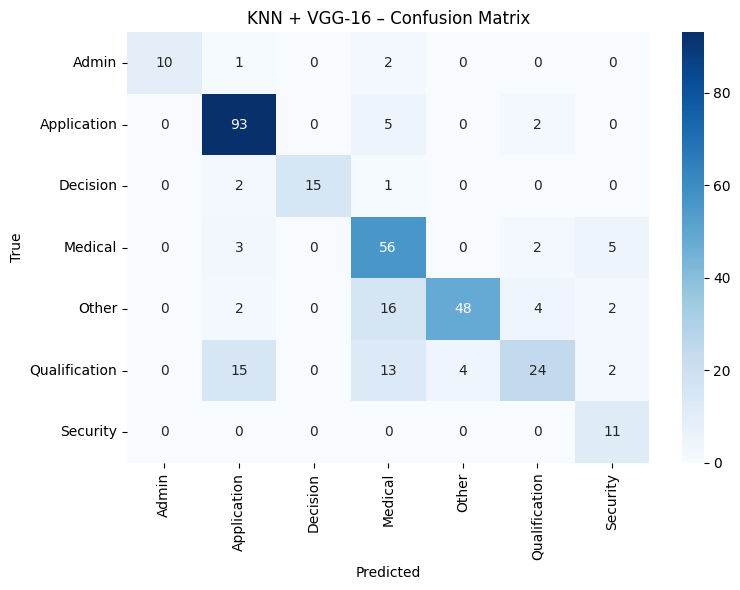

In [65]:
X_tr_n = normalize(X_tr)
X_va_n = normalize(X_va)
X_te_n = normalize(X_te)

from sklearn.metrics import f1_score

best_k, best_f1 = 5, -1
for k in [3, 5, 7, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
    knn.fit(X_tr_n, y_tr)
    preds = knn.predict(X_va_n)
    f1 = f1_score(y_va, preds, average='macro', zero_division=0)
    print(f'k={k:2d}  val macro-F1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_k = f1, k

print(f'\nBest k={best_k}')
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
knn_final.fit(np.vstack([X_tr_n, X_va_n]), np.concatenate([y_tr, y_va]))

knn_pred = knn_final.predict(X_te_n)
evaluate_model('KNN + VGG-16', y_te, knn_pred)

### 7b. XGBoost + VGG-16


──────────────────────────────────────────────────────────────────────
  XGBoost + VGG-16
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       1.00      0.77      0.87        13
  Application       0.82      0.89      0.85       100
     Decision       0.95      1.00      0.97        18
      Medical       0.74      0.80      0.77        66
        Other       0.72      0.88      0.79        72
Qualification       0.67      0.34      0.45        58
     Security       0.91      0.91      0.91        11

     accuracy                           0.78       338
    macro avg       0.83      0.80      0.80       338
 weighted avg       0.77      0.78      0.76       338



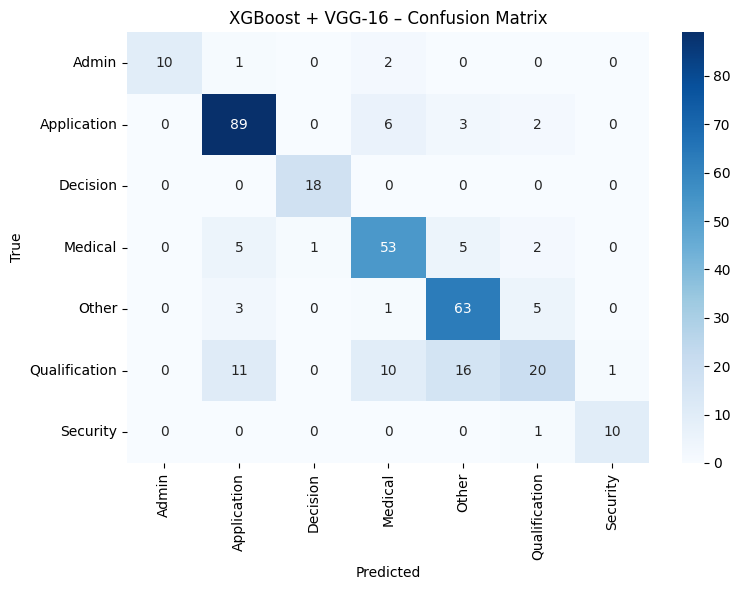

In [66]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=NUM_CLASSES,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.5,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    early_stopping_rounds=20,
    verbosity=0,
)
xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

xgb_pred = xgb.predict(X_te)
evaluate_model('XGBoost + VGG-16', y_te, xgb_pred)

### 7c. VGG-16 (fine-tuned end-to-end)

In [67]:
class PageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.paths   = df['img_path'].tolist()
        self.labels  = df['label'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), torch.tensor(self.labels[idx], dtype=torch.long)


train_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

tr_df = all_labels[all_labels['split'] == 'train']
va_df = all_labels[all_labels['split'] == 'val']
te_df = all_labels[all_labels['split'] == 'test']

tr_loader = DataLoader(PageDataset(tr_df, train_tfm), batch_size=16, shuffle=True,  num_workers=0)
va_loader = DataLoader(PageDataset(va_df, eval_tfm),  batch_size=32, shuffle=False, num_workers=0)
te_loader = DataLoader(PageDataset(te_df, eval_tfm),  batch_size=32, shuffle=False, num_workers=0)
print(f'Train batches: {len(tr_loader)}, Val: {len(va_loader)}, Test: {len(te_loader)}')

Train batches: 108, Val: 12, Test: 11


Trainable params: 119,574,535
Epoch  1  tr_loss=1.1854  tr_acc=0.5939  va_loss=0.5563  va_acc=0.7820  val_macro_f1=0.7666
Epoch  2  tr_loss=0.6619  tr_acc=0.7620  va_loss=0.6138  va_acc=0.7520  val_macro_f1=0.7477
Epoch  3  tr_loss=0.5147  tr_acc=0.8121  va_loss=0.4463  va_acc=0.8447  val_macro_f1=0.8459
Epoch  4  tr_loss=0.3671  tr_acc=0.8652  va_loss=0.4446  va_acc=0.8610  val_macro_f1=0.8679
Epoch  5  tr_loss=0.3126  tr_acc=0.8722  va_loss=0.4945  va_acc=0.8474  val_macro_f1=0.8651
Epoch  6  tr_loss=0.2194  tr_acc=0.9183  va_loss=0.5272  va_acc=0.8447  val_macro_f1=0.8553
Epoch  7  tr_loss=0.1904  tr_acc=0.9253  va_loss=0.5127  va_acc=0.8365  val_macro_f1=0.8408
Epoch  8  tr_loss=0.1662  tr_acc=0.9323  va_loss=0.4749  va_acc=0.8665  val_macro_f1=0.8701
Epoch  9  tr_loss=0.1479  tr_acc=0.9434  va_loss=0.5281  va_acc=0.8556  val_macro_f1=0.8651
Epoch 10  tr_loss=0.1514  tr_acc=0.9422  va_loss=0.5210  va_acc=0.8501  val_macro_f1=0.8619
Epoch 11  tr_loss=0.1060  tr_acc=0.9568  va_loss=0

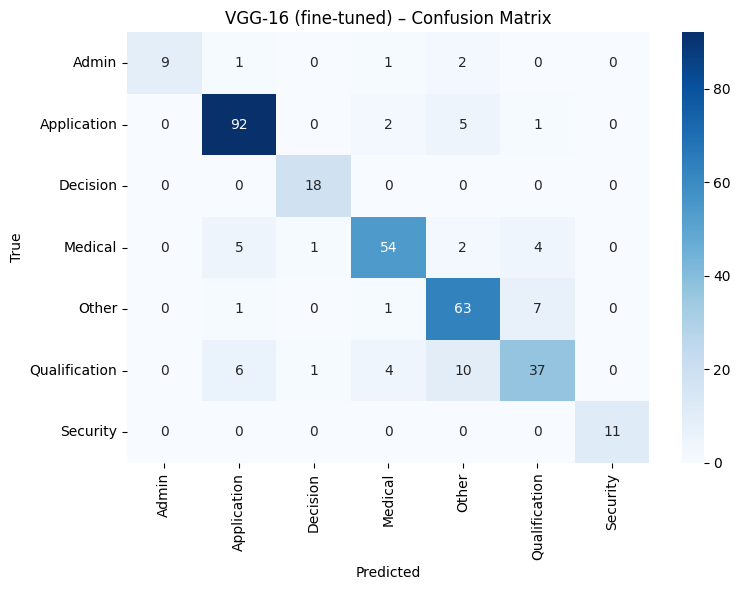

In [68]:
def build_vgg16_classifier():
    weights = models.VGG16_Weights.IMAGENET1K_V1
    model   = models.vgg16(weights=weights)
    for p in model.features.parameters():
        p.requires_grad = False
    model.classifier[6] = nn.Linear(4096, NUM_CLASSES)
    return model.to(DEVICE)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds, all_true = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())
    return np.array(all_true), np.array(all_preds)


@torch.no_grad()
def predict_loader_with_probs(model, loader):
    """Like predict_loader but also returns full (N, C) softmax probabilities."""
    model.eval()
    all_preds, all_true, all_probs = [], [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        all_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(labels.numpy())
    return np.array(all_true), np.array(all_preds), np.vstack(all_probs)


def train_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-4):
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor(y_tr, NUM_CLASSES, DEVICE))
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_f1, best_state = -1, None
    va_labels_arr = np.array(va_loader.dataset.labels)

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, tr_loader, criterion, optimizer)
        va_loss, va_acc = eval_epoch(model, va_loader, criterion)
        _, va_pred      = predict_loader(model, va_loader)
        val_f1 = f1_score(va_labels_arr, va_pred, average='macro', zero_division=0)
        scheduler.step()
        print(f'Epoch {epoch:2d}  tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  '
              f'va_loss={va_loss:.4f}  va_acc={va_acc:.4f}  val_macro_f1={val_f1:.4f}')
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


vgg16_model = build_vgg16_classifier()
print(f'Trainable params: {sum(p.numel() for p in vgg16_model.parameters() if p.requires_grad):,}')
vgg16_model = train_model(vgg16_model, tr_loader, va_loader, n_epochs=15, lr=1e-4)

vgg16_te_lbl, vgg16_te_pred = predict_loader(vgg16_model, te_loader)
evaluate_model('VGG-16 (fine-tuned)', vgg16_te_lbl, vgg16_te_pred)

### 7d. EfficientNet-B0 (fine-tuned)

Trainable params: 4,014,139
Epoch  1  tr_loss=1.7242  tr_acc=0.4230  va_loss=1.2782  va_acc=0.7493  val_macro_f1=0.7424
Epoch  2  tr_loss=1.1466  tr_acc=0.6826  va_loss=0.7464  va_acc=0.8229  val_macro_f1=0.8211
Epoch  3  tr_loss=0.7762  tr_acc=0.7474  va_loss=0.5008  va_acc=0.8311  val_macro_f1=0.8356
Epoch  4  tr_loss=0.6029  tr_acc=0.7993  va_loss=0.4256  va_acc=0.8556  val_macro_f1=0.8587
Epoch  5  tr_loss=0.4790  tr_acc=0.8390  va_loss=0.3837  va_acc=0.8529  val_macro_f1=0.8568
Epoch  6  tr_loss=0.4088  tr_acc=0.8623  va_loss=0.3580  va_acc=0.8583  val_macro_f1=0.8560
Epoch  7  tr_loss=0.3895  tr_acc=0.8646  va_loss=0.3389  va_acc=0.8665  val_macro_f1=0.8731
Epoch  8  tr_loss=0.3414  tr_acc=0.8816  va_loss=0.3371  va_acc=0.8747  val_macro_f1=0.8817
Epoch  9  tr_loss=0.3167  tr_acc=0.8874  va_loss=0.3328  va_acc=0.8665  val_macro_f1=0.8744
Epoch 10  tr_loss=0.2913  tr_acc=0.8967  va_loss=0.3330  va_acc=0.8692  val_macro_f1=0.8771
Epoch 11  tr_loss=0.2537  tr_acc=0.9072  va_loss=0.3

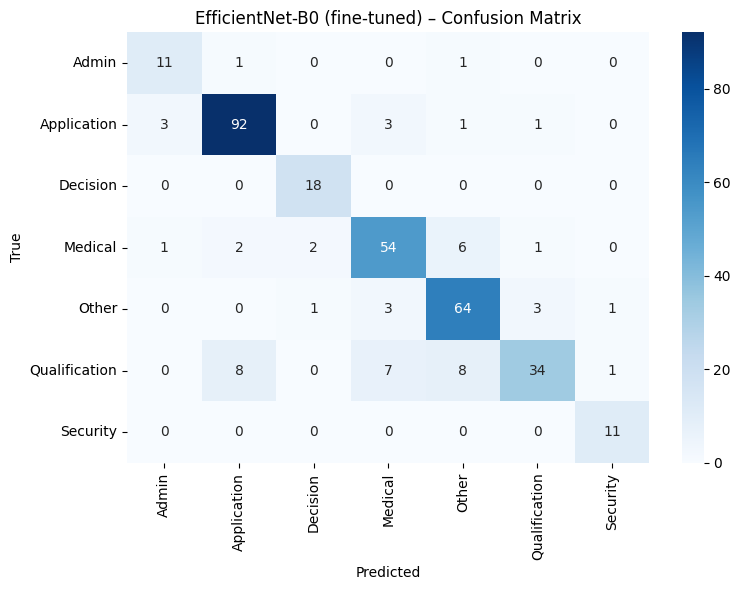

In [69]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_efficientnet():
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = efficientnet_b0(weights=weights)
    for name, p in model.named_parameters():
        if 'features.0' in name or 'features.1' in name:
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
    return model.to(DEVICE)


eff_model = build_efficientnet()
print(f'Trainable params: {sum(p.numel() for p in eff_model.parameters() if p.requires_grad):,}')
eff_model = train_model(eff_model, tr_loader, va_loader, n_epochs=15, lr=5e-5)

eff_te_lbl, eff_te_pred = predict_loader(eff_model, te_loader)
evaluate_model('EfficientNet-B0 (fine-tuned)', eff_te_lbl, eff_te_pred)
_, eff_te_pred_probs, eff_te_probs_full = predict_loader_with_probs(eff_model, te_loader)
results_probs['EfficientNet-FT'] = eff_te_probs_full


### 7e. LSTM + VGG-16

Each dossier is a sequence of pages; the bidirectional LSTM reads the 4096-D VGG-16
feature at every step and predicts the functional category at each position.

In [70]:
class DossierSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, X_feat: np.ndarray):
        self.sequences = []
        for _, grp in df.groupby('dossier'):
            idx  = grp.index.tolist()
            feats = X_feat[idx]
            lbls  = df.loc[idx, 'label'].values
            self.sequences.append(
                (torch.tensor(feats, dtype=torch.float32),
                 torch.tensor(lbls,  dtype=torch.long))
            )

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


def pad_collate(batch):
    feats_list, lbls_list = zip(*batch)
    lengths      = torch.tensor([f.size(0) for f in feats_list])
    feats_padded = nn.utils.rnn.pad_sequence(feats_list, batch_first=True)
    lbls_padded  = nn.utils.rnn.pad_sequence(lbls_list,  batch_first=True, padding_value=-1)
    return feats_padded, lbls_padded, lengths


lstm_tr_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'train'], X_all)
lstm_va_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'val'],   X_all)
lstm_te_ds = DossierSequenceDataset(all_labels[all_labels['split'] == 'test'],  X_all)

lstm_tr_loader = DataLoader(lstm_tr_ds, batch_size=4, shuffle=True,  collate_fn=pad_collate)
lstm_va_loader = DataLoader(lstm_va_ds, batch_size=4, shuffle=False, collate_fn=pad_collate)
lstm_te_loader = DataLoader(lstm_te_ds, batch_size=4, shuffle=False, collate_fn=pad_collate)
print(f'Train dossiers: {len(lstm_tr_ds)}, Val: {len(lstm_va_ds)}, Test: {len(lstm_te_ds)}')

Train dossiers: 45, Val: 10, Test: 10


In [71]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim=4096, hidden_dim=256, num_layers=2, dropout=0.3, n_classes=NUM_CLASSES):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.head = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x, lengths=None):
        x = self.proj(x)
        if lengths is not None:
            x = nn.utils.rnn.pack_padded_sequence(
                x, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
        out, _ = self.lstm(x)
        if lengths is not None:
            out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.head(out)   # (B, T, n_classes)


def train_lstm(model, tr_loader, va_loader, n_epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor(y_tr, NUM_CLASSES, DEVICE),
        ignore_index=-1,
    )
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.5)

    best_val_f1, best_state = -1, None

    for epoch in range(1, n_epochs + 1):
        model.train()
        total_loss, n = 0, 0
        for feats, lbls, lengths in tr_loader:
            feats, lbls = feats.to(DEVICE), lbls.to(DEVICE)
            optimizer.zero_grad()
            logits = model(feats, lengths)          # (B, T, C)
            B, T, C = logits.shape
            loss = criterion(logits.view(B * T, C), lbls.view(B * T))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            mask = lbls.view(B * T) != -1
            total_loss += loss.item() * mask.sum().item()
            n          += mask.sum().item()
        scheduler.step()

        model.eval()
        all_p, all_t = [], []
        with torch.no_grad():
            for feats, lbls, lengths in va_loader:
                feats = feats.to(DEVICE)
                logits = model(feats, lengths)
                B, T, C = logits.shape
                preds = logits.argmax(-1).cpu().numpy().ravel()
                truth = lbls.numpy().ravel()
                mask  = truth != -1
                all_p.extend(preds[mask])
                all_t.extend(truth[mask])
        val_f1 = f1_score(all_t, all_p, average='macro', zero_division=0)
        print(f'Epoch {epoch:2d}  loss={total_loss/max(n,1):.4f}  val_macro_f1={val_f1:.4f}')
        if val_f1 >= best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model

In [72]:
lstm_model = LSTMClassifier(input_dim=4096, hidden_dim=256, num_layers=2,
                            dropout=0.3, n_classes=NUM_CLASSES).to(DEVICE)
print(f'LSTM params: {sum(p.numel() for p in lstm_model.parameters()):,}')
lstm_model = train_lstm(lstm_model, lstm_tr_loader, lstm_va_loader, n_epochs=20, lr=1e-3)

LSTM params: 5,255,175
Epoch  1  loss=1.7718  val_macro_f1=0.4072
Epoch  2  loss=1.1039  val_macro_f1=0.5733
Epoch  3  loss=0.7397  val_macro_f1=0.7339
Epoch  4  loss=0.6365  val_macro_f1=0.8028
Epoch  5  loss=0.5393  val_macro_f1=0.8376
Epoch  6  loss=0.4264  val_macro_f1=0.8463
Epoch  7  loss=0.3707  val_macro_f1=0.8718
Epoch  8  loss=0.3017  val_macro_f1=0.8539
Epoch  9  loss=0.2599  val_macro_f1=0.8571
Epoch 10  loss=0.2377  val_macro_f1=0.8829
Epoch 11  loss=0.2171  val_macro_f1=0.8470
Epoch 12  loss=0.1751  val_macro_f1=0.8702
Epoch 13  loss=0.1462  val_macro_f1=0.8569
Epoch 14  loss=0.1405  val_macro_f1=0.8807
Epoch 15  loss=0.1174  val_macro_f1=0.8930
Epoch 16  loss=0.1094  val_macro_f1=0.8846
Epoch 17  loss=0.0887  val_macro_f1=0.8882
Epoch 18  loss=0.0786  val_macro_f1=0.8849
Epoch 19  loss=0.0697  val_macro_f1=0.8888
Epoch 20  loss=0.0700  val_macro_f1=0.8849



──────────────────────────────────────────────────────────────────────
  LSTM + VGG-16
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.92      0.85      0.88        13
  Application       0.88      0.94      0.91       100
     Decision       1.00      0.94      0.97        18
      Medical       0.70      0.89      0.79        66
        Other       0.93      0.90      0.92        72
Qualification       0.77      0.47      0.58        58
     Security       0.85      1.00      0.92        11

     accuracy                           0.84       338
    macro avg       0.86      0.86      0.85       338
 weighted avg       0.84      0.84      0.83       338



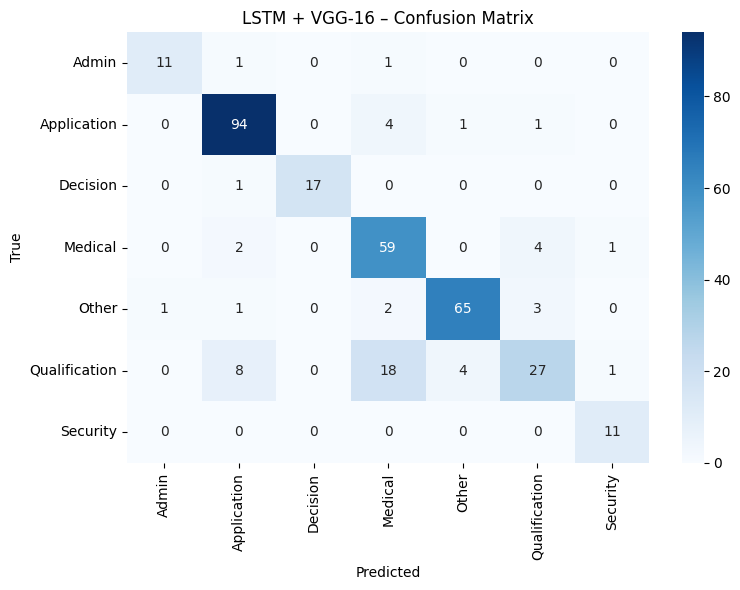

In [73]:
lstm_model.eval()
all_true_lstm, all_pred_lstm = [], []
with torch.no_grad():
    for feats, lbls, lengths in lstm_te_loader:
        feats  = feats.to(DEVICE)
        logits = lstm_model(feats, lengths)
        preds  = logits.argmax(-1).cpu().numpy()
        truth  = lbls.numpy()
        mask   = truth != -1
        all_true_lstm.extend(truth[mask].tolist())
        all_pred_lstm.extend(preds[mask].tolist())

evaluate_model('LSTM + VGG-16',
               np.array(all_true_lstm),
               np.array(all_pred_lstm))

---
## 8. Text-Only Models

### 8a. KNN + BERT


──────────────────────────────────────────────────────────────────────
  KNN-BERT
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.57      0.63      0.60        19
  Application       0.87      0.91      0.89       113
     Decision       0.94      0.83      0.88        36
      Medical       0.81      0.88      0.85        78
        Other       0.80      0.66      0.72        53
Qualification       0.90      0.76      0.82        46
     Security       0.81      1.00      0.90        22

     accuracy                           0.83       367
    macro avg       0.81      0.81      0.81       367
 weighted avg       0.84      0.83      0.83       367



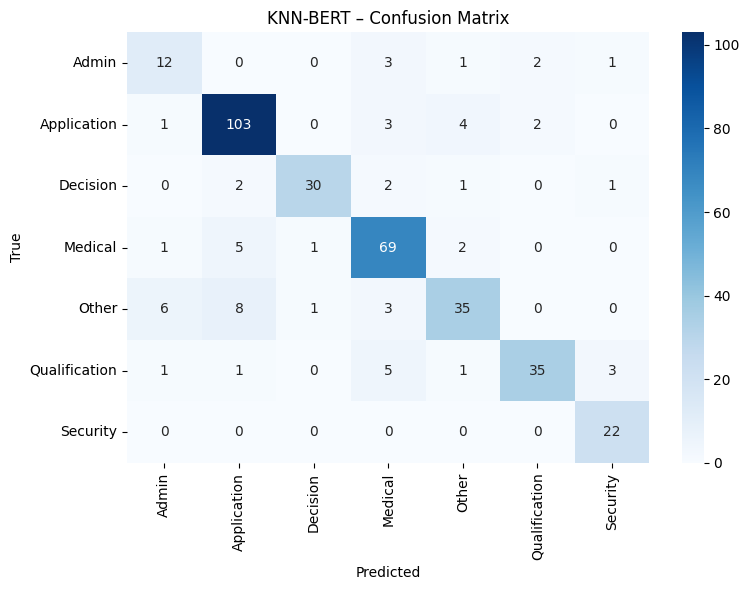


──────────────────────────────────────────────────────────────────────
  KNN-BERT
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.52      0.85      0.65        13
  Application       0.76      0.89      0.82       100
     Decision       0.94      0.89      0.91        18
      Medical       0.78      0.92      0.85        66
        Other       0.90      0.62      0.74        72
Qualification       0.90      0.66      0.76        58
     Security       0.85      1.00      0.92        11

     accuracy                           0.80       338
    macro avg       0.81      0.83      0.81       338
 weighted avg       0.82      0.80      0.80       338



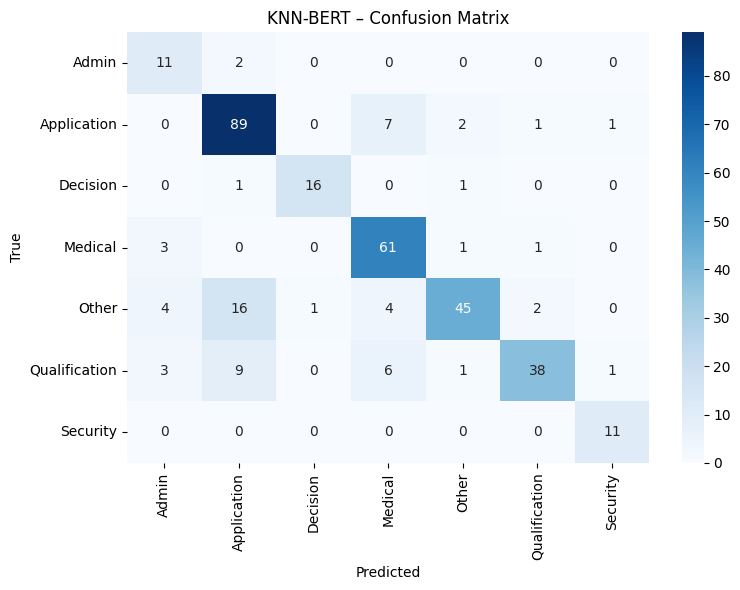

In [74]:
X_bert_tr_n = normalize(X_bert_tr)
X_bert_va_n = normalize(X_bert_va)
X_bert_te_n = normalize(X_bert_te)

knn_bert = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_bert.fit(X_bert_tr_n, y_tr)

pred_knn_bert_va = knn_bert.predict(X_bert_va_n)
pred_knn_bert_te = knn_bert.predict(X_bert_te_n)

evaluate_model('KNN-BERT', y_va, pred_knn_bert_va)
evaluate_model('KNN-BERT', y_te, pred_knn_bert_te)


### 8b. XGBoost + BERT


──────────────────────────────────────────────────────────────────────
  XGBoost-BERT
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.86      0.63      0.73        19
  Application       0.88      0.94      0.91       113
     Decision       0.97      0.81      0.88        36
      Medical       0.89      0.87      0.88        78
        Other       0.77      0.92      0.84        53
Qualification       1.00      0.89      0.94        46
     Security       1.00      0.95      0.98        22

     accuracy                           0.89       367
    macro avg       0.91      0.86      0.88       367
 weighted avg       0.89      0.89      0.89       367



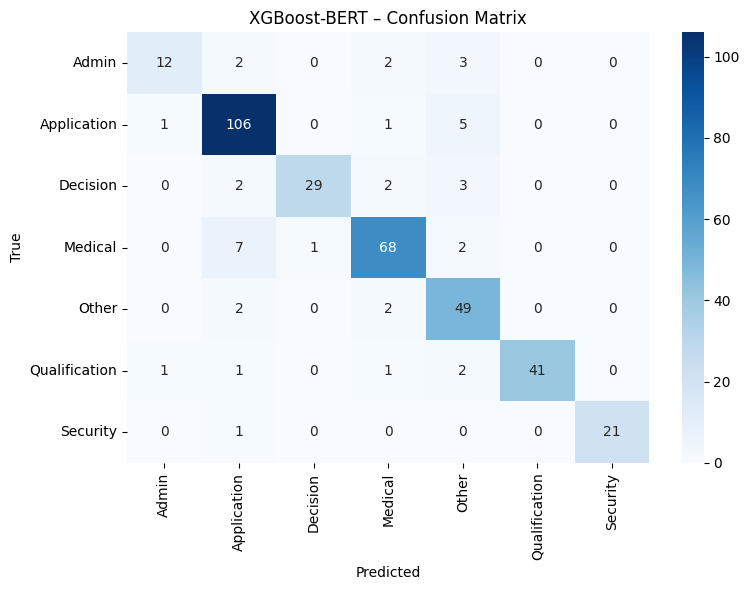


──────────────────────────────────────────────────────────────────────
  XGBoost-BERT
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.83      0.77      0.80        13
  Application       0.87      0.92      0.89       100
     Decision       1.00      0.89      0.94        18
      Medical       0.86      0.89      0.87        66
        Other       0.83      0.93      0.88        72
Qualification       0.95      0.72      0.82        58
     Security       1.00      0.91      0.95        11

     accuracy                           0.88       338
    macro avg       0.91      0.86      0.88       338
 weighted avg       0.88      0.88      0.87       338



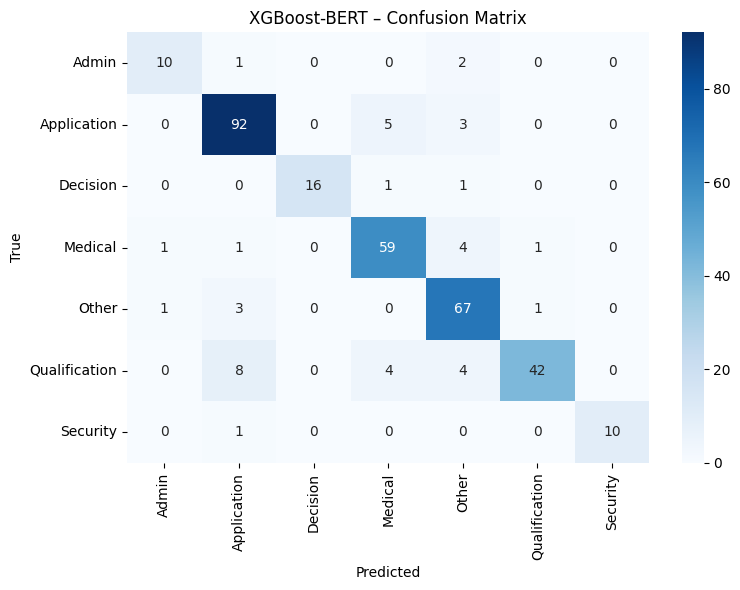

In [75]:
xgb_bert = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=20, verbosity=0,
)
xgb_bert.fit(X_bert_tr, y_tr, eval_set=[(X_bert_va, y_va)], verbose=False)

pred_xgb_bert_va = xgb_bert.predict(X_bert_va)
pred_xgb_bert_te = xgb_bert.predict(X_bert_te)

evaluate_model('XGBoost-BERT', y_va, pred_xgb_bert_va)
evaluate_model('XGBoost-BERT', y_te, pred_xgb_bert_te)


### 8c. TEXT-CNN (frozen BERT backbone + 1D-CNN)

Frozen BERT token embeddings → multi-scale 1D convolutions → max-over-time pooling → linear classifier.

TEXT-CNN trainable params: 887,815
Training TEXT-CNN …
  Epoch  1  val_macro_f1=0.8680
  Epoch  2  val_macro_f1=0.8712
  Epoch  3  val_macro_f1=0.8844
  Epoch  4  val_macro_f1=0.9014
  Epoch  5  val_macro_f1=0.9120
  Epoch  6  val_macro_f1=0.9251
  Epoch  7  val_macro_f1=0.9210
  Epoch  8  val_macro_f1=0.9144
  Epoch  9  val_macro_f1=0.9127
  Epoch 10  val_macro_f1=0.9337
  Epoch 11  val_macro_f1=0.9313
  Epoch 12  val_macro_f1=0.9287
  Epoch 13  val_macro_f1=0.9229
  Epoch 14  val_macro_f1=0.9258
  Epoch 15  val_macro_f1=0.9159

──────────────────────────────────────────────────────────────────────
  TEXT-CNN
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.52      0.85      0.65        13
  Application       0.96      0.91      0.93       100
     Decision       1.00      0.94      0.97        18
      Medical       0.86      0.92      0.89        66
        Other       0.87      0.93 

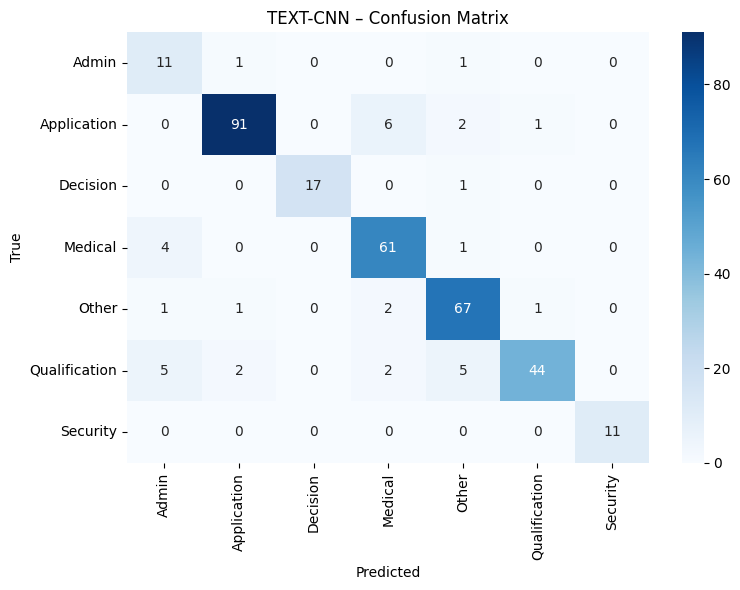

In [76]:
class TextDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_length: int = 256):
        self.texts     = [safe_read_text(p) for p in df['text_path'].tolist()]
        self.labels    = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_length

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i], padding='max_length', truncation=True,
            max_length=self.max_len, return_tensors='pt',
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.labels[i], dtype=torch.long),
        )


class TextCNN(nn.Module):
    """Frozen BERT embeddings → multi-scale 1D-CNN → max-over-time pool → MLP."""
    def __init__(
        self, bert_model,
        embed_dim: int = 768,
        num_filters: int = 128,
        filter_sizes: tuple = (2, 3, 4),
        num_classes: int = NUM_CLASSES,
        dropout: float = 0.4,
    ):
        super().__init__()
        self.bert  = bert_model
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, k) for k in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            emb = out.last_hidden_state          # (B, T, E)
        x = emb.transpose(1, 2)                  # (B, E, T)
        pooled = [
            F.max_pool1d(F.relu(conv(x)), x.size(2) - conv.kernel_size[0] + 1).squeeze(2)
            for conv in self.convs
        ]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))


def train_text_model(model, tr_loader, va_loader, n_epochs=15, lr=1e-3):
    cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
    crit = nn.CrossEntropyLoss(weight=cw)
    opt  = optim.Adam([p for p in model.parameters() if p.requires_grad],
                      lr=lr, weight_decay=1e-5)
    sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
    best_f1, best_state = -1, None
    for epoch in range(1, n_epochs + 1):
        model.train()
        for ids, mask, yb in tr_loader:
            ids, mask, yb = ids.to(DEVICE), mask.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(ids, mask), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()
        model.eval()
        preds = []
        with torch.no_grad():
            for ids, mask, _ in va_loader:
                preds.extend(
                    model(ids.to(DEVICE), mask.to(DEVICE)).argmax(1).cpu().tolist())
        f1 = f1_score(y_va, preds, average='macro', zero_division=0)
        print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
        if f1 > best_f1:
            best_f1 = f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model


def predict_text_model(model, loader):
    model.eval()
    preds, probs_list = [], []
    with torch.no_grad():
        for ids, mask, _ in loader:
            logits = model(ids.to(DEVICE), mask.to(DEVICE))
            probs_list.append(F.softmax(logits, dim=1).cpu().numpy())
            preds.extend(logits.argmax(1).cpu().tolist())
    return np.array(preds), np.vstack(probs_list)


tcnn_tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
tcnn_bert_base  = AutoModel.from_pretrained(BERT_MODEL).to(DEVICE)
for p in tcnn_bert_base.parameters():
    p.requires_grad = False

tcnn_tr_loader = DataLoader(TextDataset(tr_df, tcnn_tokenizer), batch_size=16,
                            shuffle=True,  num_workers=0)
tcnn_va_loader = DataLoader(TextDataset(va_df, tcnn_tokenizer), batch_size=16,
                            shuffle=False, num_workers=0)
tcnn_te_loader = DataLoader(TextDataset(te_df, tcnn_tokenizer), batch_size=16,
                            shuffle=False, num_workers=0)

tcnn_model = TextCNN(tcnn_bert_base).to(DEVICE)
trainable  = sum(p.numel() for p in tcnn_model.parameters() if p.requires_grad)
print(f'TEXT-CNN trainable params: {trainable:,}')

print('Training TEXT-CNN …')
tcnn_model = train_text_model(tcnn_model, tcnn_tr_loader, tcnn_va_loader,
                              n_epochs=15, lr=1e-3)
pred_tcnn_te, probs_tcnn = predict_text_model(tcnn_model, tcnn_te_loader)
evaluate_model('TEXT-CNN', y_te, pred_tcnn_te)
results_probs['TEXT-CNN'] = probs_tcnn


### 8d. BERT Fine-Tuned

BERT fine-tune total params: 109,487,623
Training BERT fine-tuned …
  Epoch  1  val_macro_f1=0.8509
  Epoch  2  val_macro_f1=0.9083
  Epoch  3  val_macro_f1=0.9088
  Epoch  4  val_macro_f1=0.9234
  Epoch  5  val_macro_f1=0.8857
  Epoch  6  val_macro_f1=0.9310
  Epoch  7  val_macro_f1=0.9157
  Epoch  8  val_macro_f1=0.9281
  Epoch  9  val_macro_f1=0.9136
  Epoch 10  val_macro_f1=0.9145

──────────────────────────────────────────────────────────────────────
  BERT Fine-Tuned
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.60      0.92      0.73        13
  Application       0.98      0.91      0.94       100
     Decision       1.00      1.00      1.00        18
      Medical       0.92      0.91      0.92        66
        Other       0.83      0.96      0.89        72
Qualification       0.94      0.78      0.85        58
     Security       1.00      1.00      1.00        11

     accu

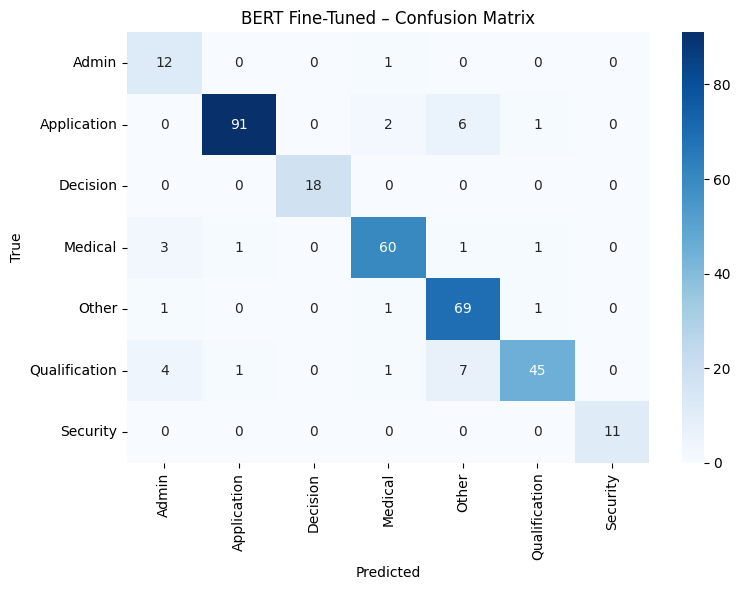

In [77]:
class BERTClassifier(nn.Module):
    def __init__(self, model_name: str = BERT_MODEL,
                 num_classes: int = NUM_CLASSES, dropout: float = 0.1):
        super().__init__()
        self.bert       = AutoModel.from_pretrained(model_name)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.bert.config.hidden_size, num_classes),
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


bert_ft_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL, use_fast=True)
bert_ft_tr_loader = DataLoader(TextDataset(tr_df, bert_ft_tokenizer), batch_size=8,
                               shuffle=True,  num_workers=0)
bert_ft_va_loader = DataLoader(TextDataset(va_df, bert_ft_tokenizer), batch_size=16,
                               shuffle=False, num_workers=0)
bert_ft_te_loader = DataLoader(TextDataset(te_df, bert_ft_tokenizer), batch_size=16,
                               shuffle=False, num_workers=0)

bert_clf = BERTClassifier().to(DEVICE)
print(f'BERT fine-tune total params: {sum(p.numel() for p in bert_clf.parameters()):,}')

print('Training BERT fine-tuned …')
bert_clf = train_text_model(bert_clf, bert_ft_tr_loader, bert_ft_va_loader,
                             n_epochs=10, lr=2e-5)
pred_bert_ft_te, probs_bert_ft = predict_text_model(bert_clf, bert_ft_te_loader)
evaluate_model('BERT Fine-Tuned', y_te, pred_bert_ft_te)
results_probs['BERT-FT'] = probs_bert_ft


---
## 9. Multimodal / Fusion Models

### 9a. KNN-Ensemble (VGG-16 + BERT concatenated features)

L2-normalised VGG-16 (4096-D) and BERT (768-D) features are concatenated to form a
4864-D vector, then KNN (cosine distance) is applied.


──────────────────────────────────────────────────────────────────────
  KNN-Ensemble
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.85      0.89      0.87        19
  Application       0.90      0.92      0.91       113
     Decision       0.97      0.89      0.93        36
      Medical       0.81      0.82      0.82        78
        Other       0.88      0.83      0.85        53
Qualification       0.80      0.78      0.79        46
     Security       0.92      1.00      0.96        22

     accuracy                           0.87       367
    macro avg       0.87      0.88      0.88       367
 weighted avg       0.87      0.87      0.87       367



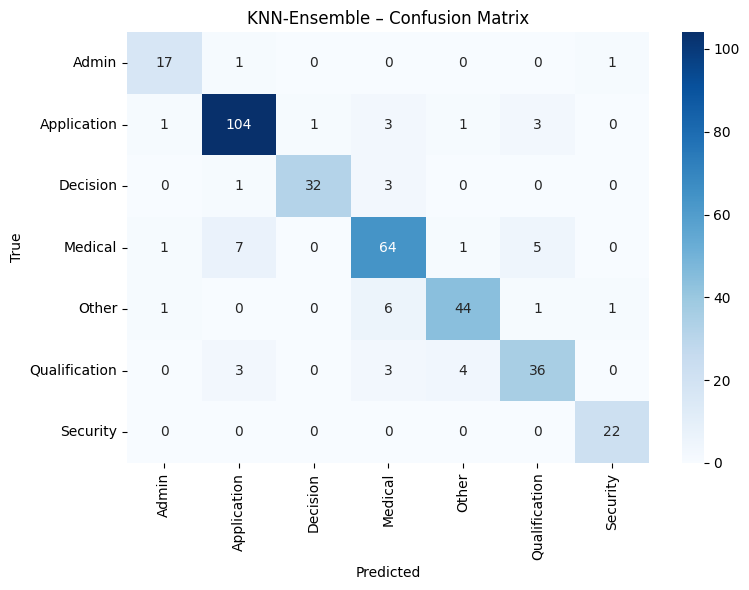


──────────────────────────────────────────────────────────────────────
  KNN-Ensemble
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.79      0.85      0.81        13
  Application       0.89      0.92      0.91       100
     Decision       1.00      0.94      0.97        18
      Medical       0.67      0.97      0.79        66
        Other       0.88      0.71      0.78        72
Qualification       0.86      0.52      0.65        58
     Security       0.73      1.00      0.85        11

     accuracy                           0.82       338
    macro avg       0.83      0.84      0.82       338
 weighted avg       0.84      0.82      0.81       338



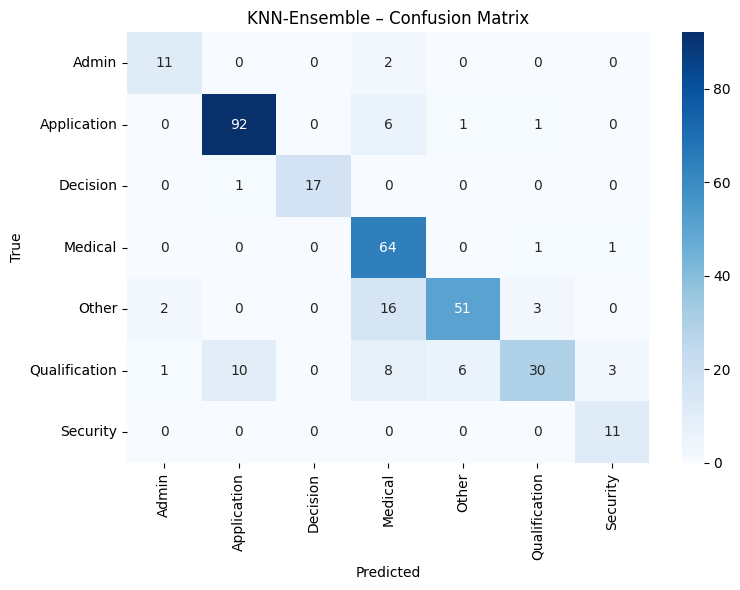

In [78]:
X_ens_tr = np.hstack([normalize(X_tr), normalize(X_bert_tr)])
X_ens_va = np.hstack([normalize(X_va), normalize(X_bert_va)])
X_ens_te = np.hstack([normalize(X_te), normalize(X_bert_te)])

knn_ens = KNeighborsClassifier(n_neighbors=7, metric='cosine', n_jobs=-1)
knn_ens.fit(X_ens_tr, y_tr)

pred_knn_ens_va = knn_ens.predict(X_ens_va)
pred_knn_ens_te = knn_ens.predict(X_ens_te)

evaluate_model('KNN-Ensemble', y_va, pred_knn_ens_va)
evaluate_model('KNN-Ensemble', y_te, pred_knn_ens_te)


### 9b. XGBoost-Ensemble (VGG-16 + BERT concatenated features)


──────────────────────────────────────────────────────────────────────
  XGBoost-Ensemble
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.88      0.74      0.80        19
  Application       0.93      0.98      0.96       113
     Decision       1.00      0.92      0.96        36
      Medical       0.93      0.91      0.92        78
        Other       0.86      0.96      0.91        53
Qualification       0.98      0.87      0.92        46
     Security       0.96      1.00      0.98        22

     accuracy                           0.93       367
    macro avg       0.93      0.91      0.92       367
 weighted avg       0.93      0.93      0.93       367



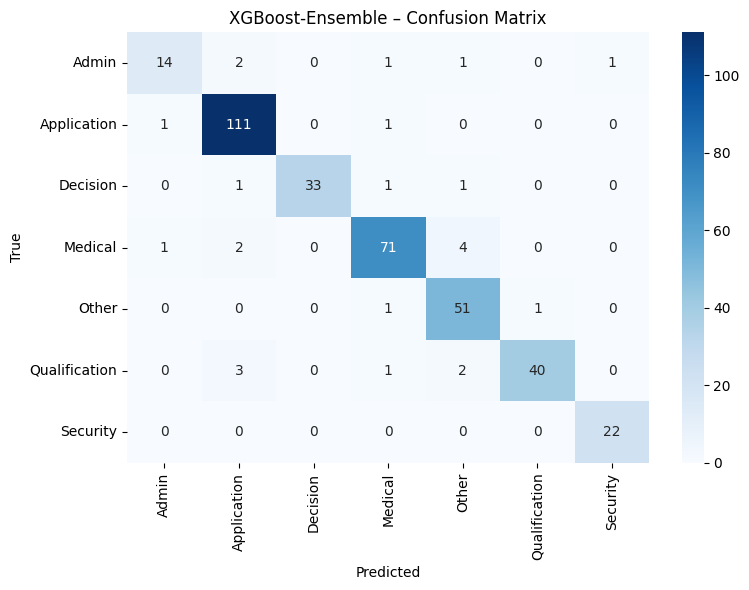


──────────────────────────────────────────────────────────────────────
  XGBoost-Ensemble
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.92      0.85      0.88        13
  Application       0.89      0.93      0.91       100
     Decision       1.00      0.94      0.97        18
      Medical       0.84      0.95      0.89        66
        Other       0.89      0.94      0.92        72
Qualification       0.91      0.67      0.77        58
     Security       1.00      1.00      1.00        11

     accuracy                           0.89       338
    macro avg       0.92      0.90      0.91       338
 weighted avg       0.90      0.89      0.89       338



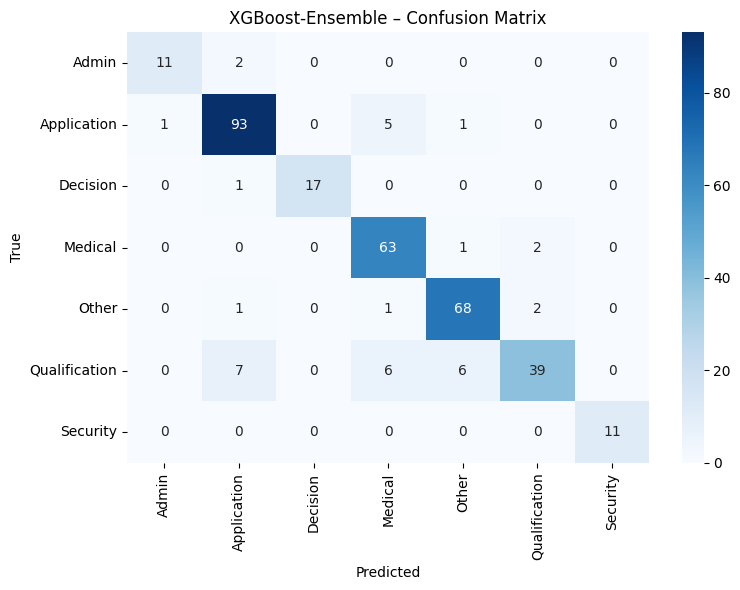

In [79]:
xgb_ens = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.5,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=RANDOM_SEED, n_jobs=-1,
    early_stopping_rounds=20, verbosity=0,
)
xgb_ens.fit(X_ens_tr, y_tr, eval_set=[(X_ens_va, y_va)], verbose=False)

pred_xgb_ens_va = xgb_ens.predict(X_ens_va)
pred_xgb_ens_te = xgb_ens.predict(X_ens_te)

evaluate_model('XGBoost-Ensemble', y_va, pred_xgb_ens_va)
evaluate_model('XGBoost-Ensemble', y_te, pred_xgb_ens_te)


### 9c. Early Fusion — EfficientNet-B0 + BERT → MLP

Frozen EfficientNet-B0 (1280-D) and frozen BERT [CLS] (768-D) features are
**projected independently** then concatenated and passed through an MLP head.

  Epoch  1  val_macro_f1=0.8155
  Epoch  2  val_macro_f1=0.8488
  Epoch  3  val_macro_f1=0.9157
  Epoch  4  val_macro_f1=0.8849
  Epoch  5  val_macro_f1=0.9231
  Epoch  6  val_macro_f1=0.9298
  Epoch  7  val_macro_f1=0.9179
  Epoch  8  val_macro_f1=0.9181
  Epoch  9  val_macro_f1=0.9174
  Epoch 10  val_macro_f1=0.9098
  Epoch 11  val_macro_f1=0.9222
  Epoch 12  val_macro_f1=0.9139
  Epoch 13  val_macro_f1=0.9158
  Epoch 14  val_macro_f1=0.9176
  Epoch 15  val_macro_f1=0.9092
  Epoch 16  val_macro_f1=0.9164
  Epoch 17  val_macro_f1=0.9164
  Epoch 18  val_macro_f1=0.9154
  Epoch 19  val_macro_f1=0.9125
  Epoch 20  val_macro_f1=0.9203

──────────────────────────────────────────────────────────────────────
  Early Fusion EfficientNet+BERT
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.85      0.85      0.85        13
  Application       0.95      0.92      0.93       100
     Decision     

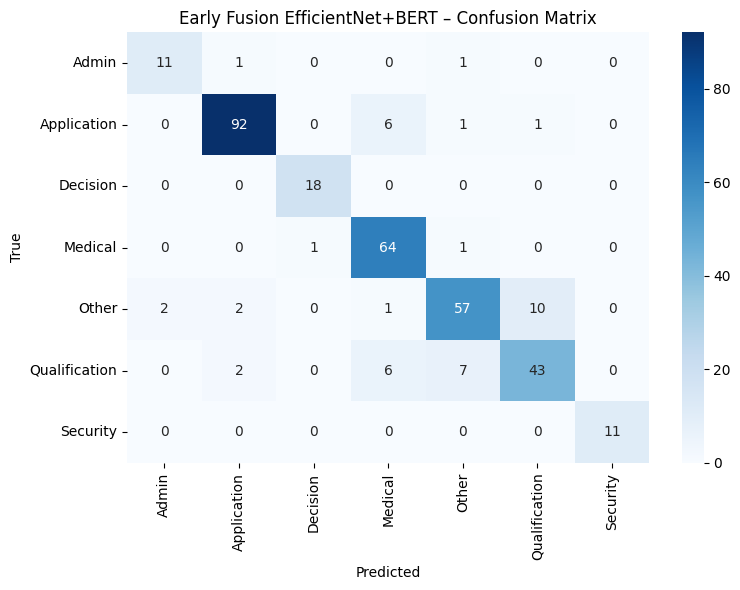

In [80]:
class EarlyFusionDataset(Dataset):
    def __init__(self, img_feats: np.ndarray, text_feats: np.ndarray,
                 labels: np.ndarray):
        self.img    = torch.tensor(img_feats,  dtype=torch.float32)
        self.text   = torch.tensor(text_feats, dtype=torch.float32)
        self.labels = torch.tensor(labels,     dtype=torch.long)

    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.img[i], self.text[i], self.labels[i]


class EarlyFusionClassifier(nn.Module):
    def __init__(self, img_dim=1280, text_dim=768,
                 hidden=512, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.img_proj  = nn.Linear(img_dim,  hidden)
        self.text_proj = nn.Linear(text_dim, hidden)
        self.head = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, img_feat, text_feat):
        return self.head(torch.cat([
            self.img_proj(img_feat),
            self.text_proj(text_feat),
        ], dim=1))


ef_tr_loader = DataLoader(
    EarlyFusionDataset(X_eff_tr, X_bert_tr, y_tr), batch_size=32, shuffle=True)
ef_va_loader = DataLoader(
    EarlyFusionDataset(X_eff_va, X_bert_va, y_va), batch_size=32, shuffle=False)
ef_te_loader = DataLoader(
    EarlyFusionDataset(X_eff_te, X_bert_te, y_te), batch_size=32, shuffle=False)

ef_model = EarlyFusionClassifier().to(DEVICE)
cw   = class_weights_tensor(y_tr, NUM_CLASSES, DEVICE)
crit = nn.CrossEntropyLoss(weight=cw)
opt  = optim.Adam(ef_model.parameters(), lr=1e-3, weight_decay=1e-5)
sch  = optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)

best_f1, best_state = -1, None
for epoch in range(1, 21):
    ef_model.train()
    for img_f, txt_f, yb in ef_tr_loader:
        img_f, txt_f, yb = img_f.to(DEVICE), txt_f.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        crit(ef_model(img_f, txt_f), yb).backward()
        opt.step()
    sch.step()
    ef_model.eval()
    preds = []
    with torch.no_grad():
        for img_f, txt_f, _ in ef_va_loader:
            preds.extend(
                ef_model(img_f.to(DEVICE), txt_f.to(DEVICE)).argmax(1).cpu().tolist())
    f1 = f1_score(y_va, preds, average='macro', zero_division=0)
    print(f'  Epoch {epoch:2d}  val_macro_f1={f1:.4f}')
    if f1 > best_f1:
        best_f1, best_state = f1, {k: v.clone() for k, v in ef_model.state_dict().items()}

ef_model.load_state_dict(best_state)
ef_model.eval()
pred_ef_te, probs_ef = [], []
with torch.no_grad():
    for img_f, txt_f, _ in ef_te_loader:
        logits = ef_model(img_f.to(DEVICE), txt_f.to(DEVICE))
        probs_ef.append(F.softmax(logits, dim=1).cpu().numpy())
        pred_ef_te.extend(logits.argmax(1).cpu().tolist())
pred_ef_te = np.array(pred_ef_te)
probs_ef   = np.vstack(probs_ef)

evaluate_model('Early Fusion EfficientNet+BERT', y_te, pred_ef_te)
results_probs['EarlyFusion'] = probs_ef


### 9d. Late Fusion — EfficientNet-B0 FT + BERT FT (average softmax)

The softmax probability vectors from the individually trained `EfficientNet-FT` and
`BERT-FT` models are averaged to produce the final prediction.


──────────────────────────────────────────────────────────────────────
  Late Fusion EfficientNet+BERT
──────────────────────────────────────────────────────────────────────
               precision    recall  f1-score   support

        Admin       0.63      0.92      0.75        13
  Application       0.98      0.92      0.95       100
     Decision       1.00      1.00      1.00        18
      Medical       0.91      0.92      0.92        66
        Other       0.85      0.96      0.90        72
Qualification       0.96      0.79      0.87        58
     Security       1.00      1.00      1.00        11

     accuracy                           0.91       338
    macro avg       0.90      0.93      0.91       338
 weighted avg       0.92      0.91      0.92       338



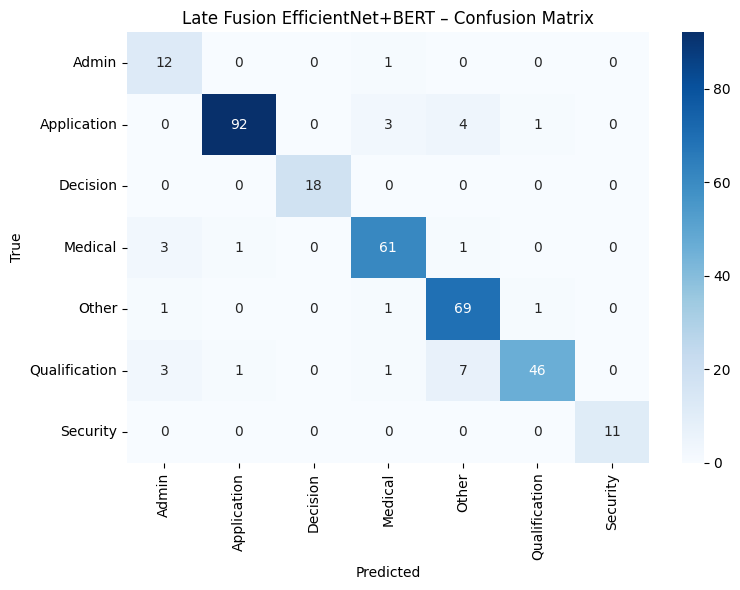

In [81]:
probs_bert_arr = results_probs['BERT-FT']          # (N_te, NUM_CLASSES)
probs_eff_arr  = results_probs['EfficientNet-FT']  # (N_te, NUM_CLASSES)

probs_late = (probs_bert_arr + probs_eff_arr) / 2.0
pred_late  = probs_late.argmax(axis=1)

evaluate_model('Late Fusion EfficientNet+BERT', y_te, pred_late)
results_probs['LateFusion'] = probs_late


## 10. Summary

In [82]:
summary_df = (
    pd.DataFrame(results_summary).T
      .round(4)
)
summary_df.index.name = 'Model'
print(summary_df[['accuracy', 'macro_f1', 'weighted_f1']].to_string())
summary_df

                                accuracy  macro_f1  weighted_f1
Model                                                          
KNN + VGG-16                      0.7604    0.7659       0.7537
XGBoost + VGG-16                  0.7781    0.8026       0.7636
VGG-16 (fine-tuned)               0.8402    0.8595       0.8377
EfficientNet-B0 (fine-tuned)      0.8402    0.8410       0.8356
LSTM + VGG-16                     0.8402    0.8513       0.8324
KNN-BERT                          0.8018    0.8062       0.7991
XGBoost-BERT                      0.8757    0.8800       0.8747
TEXT-CNN                          0.8935    0.8840       0.8960
BERT Fine-Tuned                   0.9053    0.9037       0.9070
KNN-Ensemble                      0.8166    0.8227       0.8109
XGBoost-Ensemble                  0.8935    0.9069       0.8906
Early Fusion EfficientNet+BERT    0.8757    0.8909       0.8745
Late Fusion EfficientNet+BERT     0.9142    0.9122       0.9154


,accuracy,macro_f1,weighted_f1,f1_Admin,f1_Application,f1_Decision,f1_Medical,f1_Other,f1_Qualification,f1_Security
Model,,,,,,,,,,
KNN + VGG-16,0.7604,0.7659,0.7537,0.8696,0.8611,0.9091,0.7044,0.7742,0.5333,0.7097
XGBoost + VGG-16,0.7781,0.8026,0.7636,0.8696,0.8517,0.9730,0.7681,0.7925,0.4545,0.9091
VGG-16 (fine-tuned),0.8402,0.8595,0.8377,0.8182,0.8976,0.9474,0.8438,0.8182,0.6916,1.0000
EfficientNet-B0 (fine-tuned),0.8402,0.8410,0.8356,0.7857,0.9064,0.9231,0.8120,0.8421,0.7010,0.9167
LSTM + VGG-16,0.8402,0.8513,0.8324,0.8800,0.9082,0.9714,0.7867,0.9155,0.5806,0.9167
KNN-BERT,0.8018,0.8062,0.7991,0.6471,0.8203,0.9143,0.8472,0.7377,0.7600,0.9167
XGBoost-BERT,0.8757,0.8800,0.8747,0.8000,0.8932,0.9412,0.8741,0.8758,0.8235,0.9524
TEXT-CNN,0.8935,0.8840,0.8960,0.6471,0.9333,0.9714,0.8905,0.8993,0.8462,1.0000
BERT Fine-Tuned,0.9053,0.9037,0.9070,0.7273,0.9430,1.0000,0.9160,0.8903,0.8491,1.0000


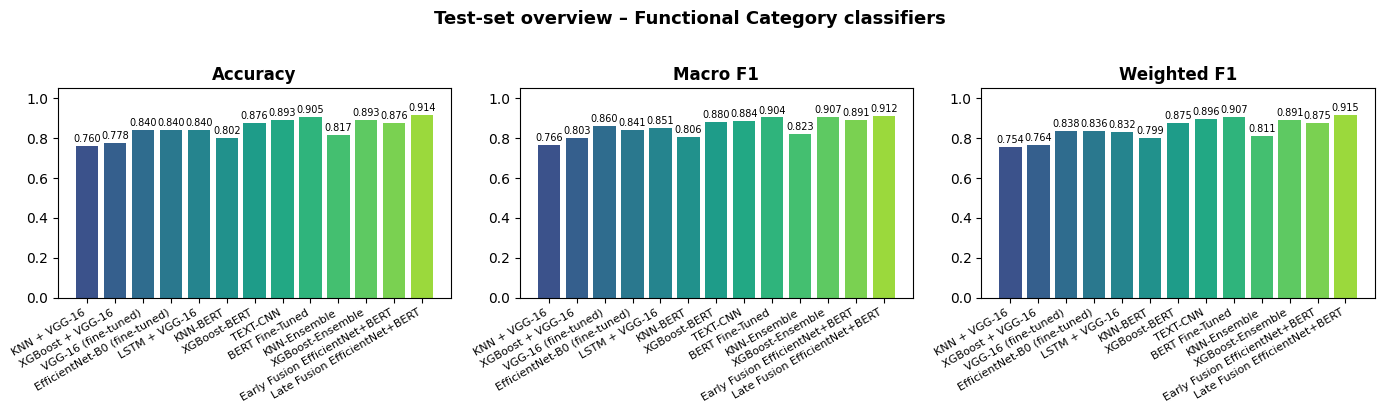

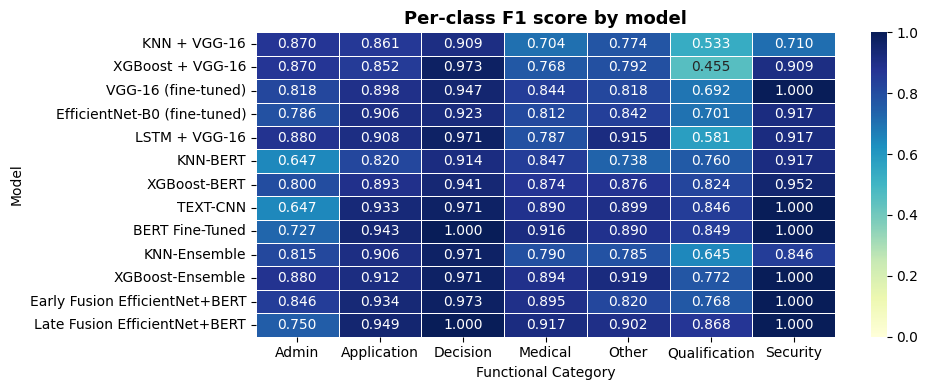

Figures saved.


In [83]:
# ── Bar chart: accuracy / macro-F1 / weighted-F1 ────────────────────────────
overview_metrics = ['accuracy', 'macro_f1', 'weighted_f1']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, overview_metrics):
    vals   = summary_df[metric].astype(float)
    colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(vals)))
    bars   = ax.bar(vals.index, vals.values, color=colors)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=30, ha='right', fontsize=8)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Test-set overview – Functional Category classifiers',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(WORKSPACE / 'func_cat_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class F1 heatmap ─────────────────────────────────────────────────────
f1_cols = [f'f1_{n}' for n in SHORT_NAMES]
f1_df   = summary_df[f1_cols].astype(float)
f1_df.columns = SHORT_NAMES

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Per-class F1 score by model', fontsize=13, fontweight='bold')
ax.set_xlabel('Functional Category')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(WORKSPACE / 'func_cat_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures saved.')